# Phase 1 Step 2 — 탐색적 데이터 분석 (EDA)

**목표:** WM-811K 데이터셋의 클래스 분포, 불량 패턴의 시각적 특성, 공간적 분포를 파악하여 전처리 전략을 수립한다.

| 항목 | 내용 |
|------|------|
| 분석 대상 | 레이블 있는 172,950개 샘플 |
| 제외 데이터 | `unknown` (638,507개, 미레이블) |
| 클래스 수 | 9종 불량 + none (총 10 클래스) |
| 산출물 | `analysis/` 폴더 내 시각화 이미지, CSV, 리포트 |

## 1. 환경 설정

In [1]:
import os
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats

warnings.filterwarnings('ignore')

# ── 한글 폰트 설정 (Windows: Malgun Gothic)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 100

# ── 경로 설정
DATA_PATH   = Path('data/raw/LSWMD.pkl')
ANALYSIS_DIR = Path('analysis')
ANALYSIS_DIR.mkdir(exist_ok=True)

# ── 시드 고정
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# ── 클래스 순서 및 컬러 팔레트 정의
CLASS_ORDER = ['none', 'Center', 'Donut', 'Edge-Loc', 'Edge-Ring',
               'Loc', 'Near-full', 'Random', 'Scratch']
CLASS_COLORS = [
    '#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2',
    '#937860', '#DA8BC3', '#8C8C8C', '#CCB974'
]
COLOR_MAP = dict(zip(CLASS_ORDER, CLASS_COLORS))

# ── 웨이퍼 맵 시각화용 커스텀 컬러맵 (0=흰색, 1=파랑, 2=빨강)
WAFER_CMAP = mcolors.ListedColormap(['#FFFFFF', '#4C72B0', '#C44E52'])
WAFER_NORM = mcolors.BoundaryNorm([0, 0.5, 1.5, 2.5], WAFER_CMAP.N)

print('환경 설정 완료')
print(f'분석 결과 저장 경로: {ANALYSIS_DIR.resolve()}')

환경 설정 완료
분석 결과 저장 경로: C:\Users\naisk\Desktop\하이닉스 대비\웨이퍼 불량 분석\analysis


## 2. 데이터 로드 및 레이블 정제

In [2]:
print('pickle 로드 중... (약 30~60초 소요)')
df = pd.read_pickle(DATA_PATH)
print(f'로드 완료: {df.shape[0]:,}행 x {df.shape[1]}열')

# 중첩 리스트 정제
def extract_label(val):
    if isinstance(val, (list, np.ndarray)):
        flat = np.array(val).flatten()
        return str(flat[0]) if len(flat) > 0 else 'unknown'
    return str(val)

df['failureType_clean']    = df['failureType'].apply(extract_label)
df['trianTestLabel_clean'] = df['trianTestLabel'].apply(extract_label)

# 미레이블 데이터 분리
labeled_df   = df[df['failureType_clean'] != 'unknown'].copy()
unlabeled_df = df[df['failureType_clean'] == 'unknown'].copy()

print(f'레이블 데이터:   {len(labeled_df):,}개')
print(f'미레이블 데이터: {len(unlabeled_df):,}개')
print(f'클래스 목록: {sorted(labeled_df["failureType_clean"].unique())}')

pickle 로드 중... (약 30~60초 소요)
로드 완료: 811,457행 x 6열
레이블 데이터:   172,950개
미레이블 데이터: 638,507개
클래스 목록: ['Center', 'Donut', 'Edge-Loc', 'Edge-Ring', 'Loc', 'Near-full', 'Random', 'Scratch', 'none']


## 3. 전체 데이터 현황 요약

In [3]:
n_total    = len(df)
n_labeled  = len(labeled_df)
n_unlabeled = len(unlabeled_df)
dist = labeled_df['failureType_clean'].value_counts()
n_none    = dist.get('none', 0)
n_defects = n_labeled - n_none

print('=' * 55)
print('  WM-811K 데이터셋 현황')
print('=' * 55)
print(f'  전체 샘플 수:          {n_total:>8,}')
print(f'  ├─ 레이블 있음:        {n_labeled:>8,}  ({n_labeled/n_total*100:.1f}%)')
print(f'  │   ├─ 정상 (none):    {n_none:>8,}  ({n_none/n_labeled*100:.1f}%)')
print(f'  │   └─ 불량 (8종):    {n_defects:>8,}  ({n_defects/n_labeled*100:.1f}%)')
print(f'  └─ 미레이블 (unknown): {n_unlabeled:>8,}  ({n_unlabeled/n_total*100:.1f}%)')
print()
print(f'  클래스별 분포 (레이블 {n_labeled:,}개 기준):')
print(f"  {'클래스':<12} {'샘플 수':>8}  {'비율':>7}  {'누적 비율':>9}")
print(f"  {'-'*42}")
cumsum = 0
for cls in CLASS_ORDER:
    cnt = dist.get(cls, 0)
    pct = cnt / n_labeled * 100
    cumsum += pct
    print(f'  {cls:<12} {cnt:>8,}  {pct:>6.2f}%  {cumsum:>8.2f}%')
print()
print(f'  Imbalance Ratio: {dist.max()/dist.min():.1f}x  (none {n_none:,} vs Near-full {dist.get("Near-full",0)})')

  WM-811K 데이터셋 현황
  전체 샘플 수:           811,457
  ├─ 레이블 있음:         172,950  (21.3%)
  │   ├─ 정상 (none):     147,431  (85.2%)
  │   └─ 불량 (8종):      25,519  (14.8%)
  └─ 미레이블 (unknown):  638,507  (78.7%)

  클래스별 분포 (레이블 172,950개 기준):
  클래스              샘플 수       비율      누적 비율
  ------------------------------------------
  none          147,431   85.24%     85.24%
  Center          4,294    2.48%     87.73%
  Donut             555    0.32%     88.05%
  Edge-Loc        5,189    3.00%     91.05%
  Edge-Ring       9,680    5.60%     96.65%
  Loc             3,593    2.08%     98.72%
  Near-full         149    0.09%     98.81%
  Random            866    0.50%     99.31%
  Scratch         1,193    0.69%    100.00%

  Imbalance Ratio: 989.5x  (none 147,431 vs Near-full 149)


## 4. 클래스 분포 시각화

### 4-1. 전체 데이터 비율 (레이블 vs 미레이블)

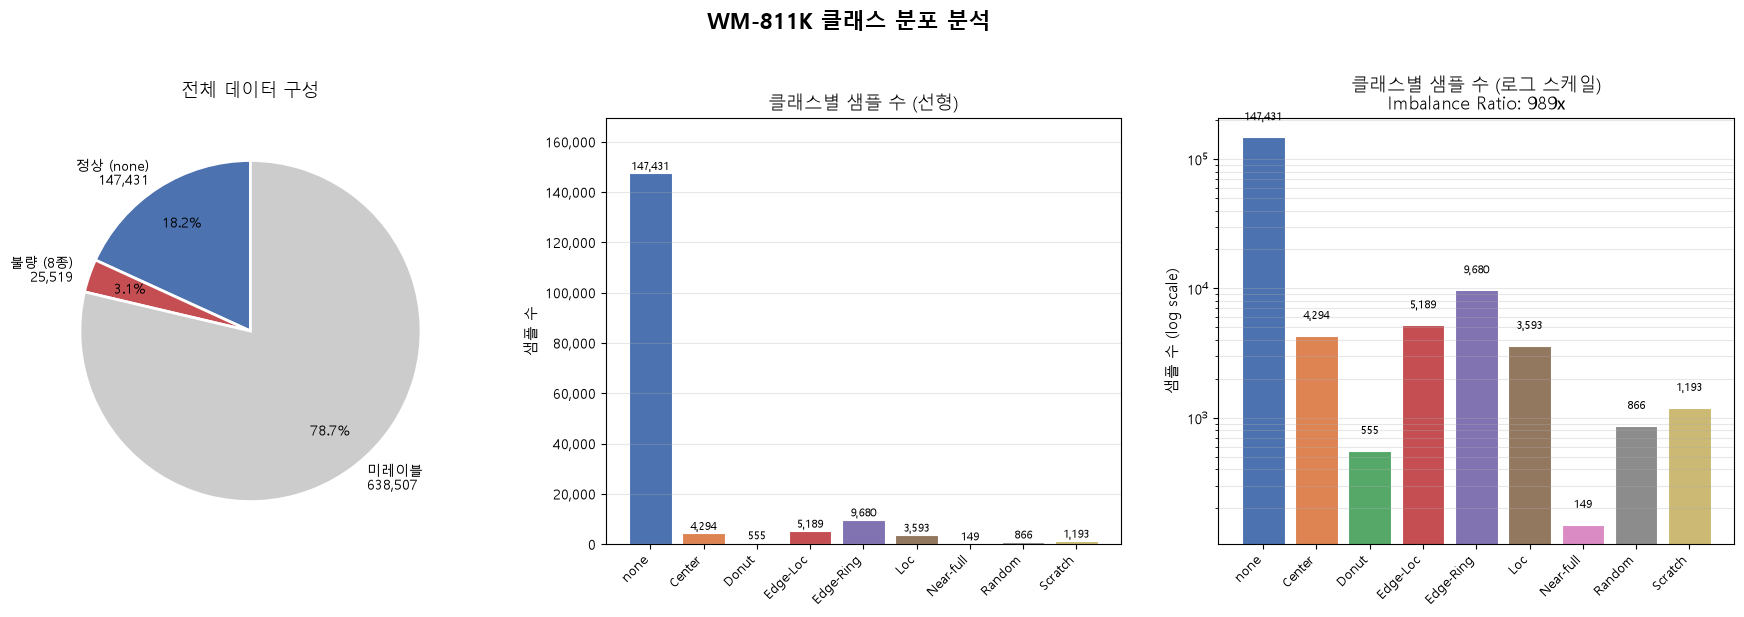

저장 완료: analysis\class_distribution.png


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('WM-811K 클래스 분포 분석', fontsize=16, fontweight='bold', y=1.02)

# ── (1) 전체 vs 레이블 vs 미레이블 파이 차트
ax1 = axes[0]
sizes1 = [n_none, n_defects, n_unlabeled]
labels1 = [f'정상 (none)\n{n_none:,}', f'불량 (8종)\n{n_defects:,}', f'미레이블\n{n_unlabeled:,}']
colors1 = ['#4C72B0', '#C44E52', '#CCCCCC']
wedges, texts, autotexts = ax1.pie(
    sizes1, labels=labels1, colors=colors1, autopct='%1.1f%%',
    startangle=90, pctdistance=0.75,
    wedgeprops=dict(edgecolor='white', linewidth=2)
)
for t in autotexts: t.set_fontsize(10)
ax1.set_title('전체 데이터 구성', fontsize=13, pad=15)

# ── (2) 레이블 데이터 클래스별 바 차트 (로그 스케일)
ax2 = axes[1]
counts = [dist.get(c, 0) for c in CLASS_ORDER]
colors2 = CLASS_COLORS
bars = ax2.bar(range(len(CLASS_ORDER)), counts, color=colors2, edgecolor='white', linewidth=0.8)
ax2.set_xticks(range(len(CLASS_ORDER)))
ax2.set_xticklabels(CLASS_ORDER, rotation=45, ha='right', fontsize=9)
ax2.set_ylabel('샘플 수', fontsize=11)
ax2.set_title('클래스별 샘플 수 (선형)', fontsize=13)
for bar, cnt in zip(bars, counts):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
             f'{cnt:,}', ha='center', va='bottom', fontsize=8, rotation=0)
ax2.set_ylim(0, max(counts) * 1.15)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax2.grid(axis='y', alpha=0.3)

# ── (3) 로그 스케일 바 차트 (불균형 강조)
ax3 = axes[2]
bars3 = ax3.bar(range(len(CLASS_ORDER)), counts, color=colors2, edgecolor='white', linewidth=0.8)
ax3.set_yscale('log')
ax3.set_xticks(range(len(CLASS_ORDER)))
ax3.set_xticklabels(CLASS_ORDER, rotation=45, ha='right', fontsize=9)
ax3.set_ylabel('샘플 수 (log scale)', fontsize=11)
ax3.set_title(f'클래스별 샘플 수 (로그 스케일)\nImbalance Ratio: {dist.max()//dist.min()}x', fontsize=13)
for bar, cnt in zip(bars3, counts):
    ax3.text(bar.get_x() + bar.get_width()/2, cnt * 1.3,
             f'{cnt:,}', ha='center', va='bottom', fontsize=8)
ax3.grid(axis='y', alpha=0.3, which='both')

plt.tight_layout()
save_path = ANALYSIS_DIR / 'class_distribution.png'
plt.savefig(save_path, bbox_inches='tight', dpi=150)
plt.show()
print(f'저장 완료: {save_path}')

## 5. 클래스별 샘플 이미지 갤러리

각 클래스별 5개 샘플 웨이퍼 맵을 시각화한다.  
색상: **흰색** = 빈 영역, **파랑** = 정상 다이, **빨강** = 불량 다이

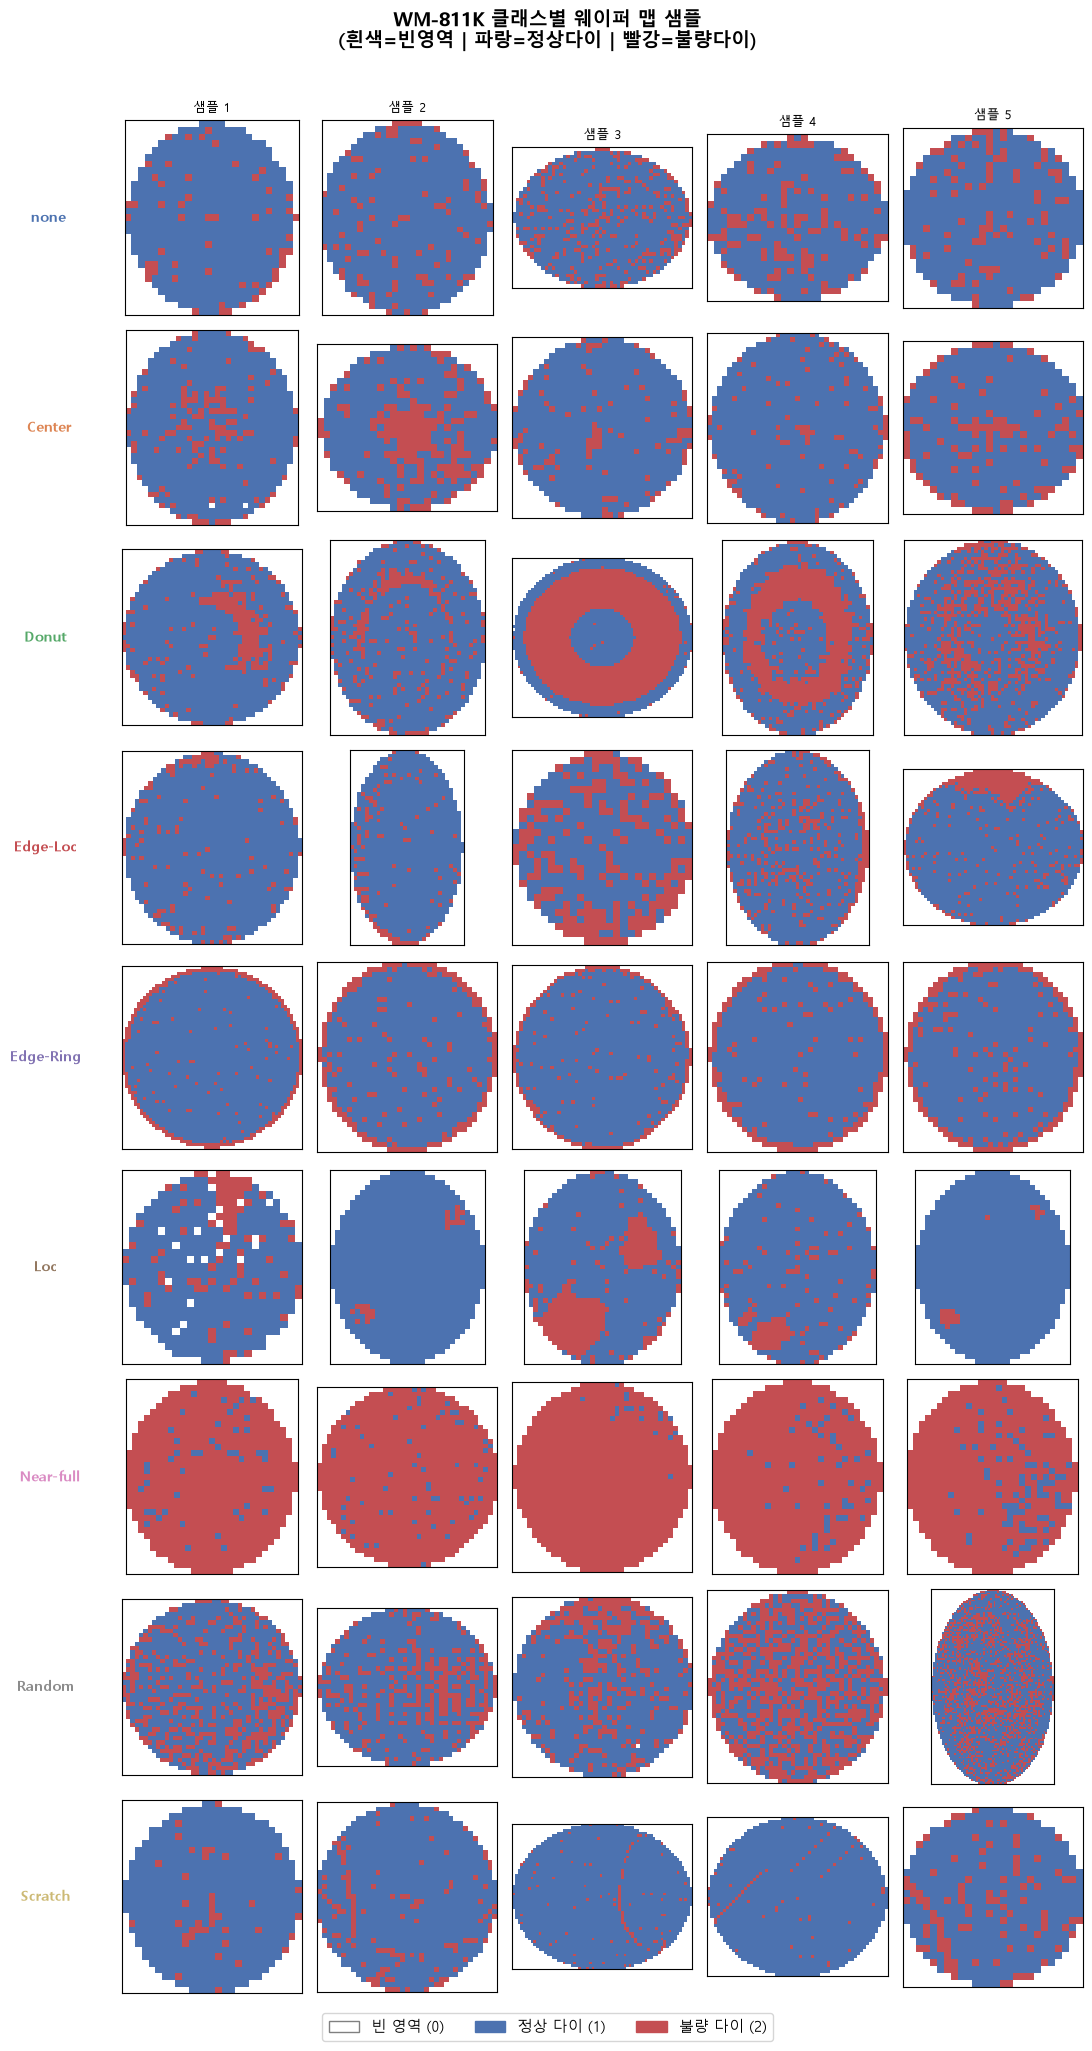

저장 완료: analysis\sample_gallery.png


In [5]:
N_SAMPLES = 5
n_classes = len(CLASS_ORDER)

fig, axes = plt.subplots(n_classes, N_SAMPLES, figsize=(N_SAMPLES * 2.2, n_classes * 2.2))
fig.suptitle('WM-811K 클래스별 웨이퍼 맵 샘플\n(흰색=빈영역 | 파랑=정상다이 | 빨강=불량다이)',
             fontsize=14, fontweight='bold', y=1.01)

for row, cls in enumerate(CLASS_ORDER):
    cls_df = labeled_df[labeled_df['failureType_clean'] == cls]
    samples = cls_df.sample(n=min(N_SAMPLES, len(cls_df)), random_state=SEED)

    for col in range(N_SAMPLES):
        ax = axes[row][col]
        if col < len(samples):
            wmap = samples.iloc[col]['waferMap'].astype(float)
            ax.imshow(wmap, cmap=WAFER_CMAP, norm=WAFER_NORM, interpolation='nearest')
        else:
            ax.axis('off')
        ax.set_xticks([])
        ax.set_yticks([])
        if col == 0:
            ax.set_ylabel(cls, fontsize=10, fontweight='bold',
                         color=COLOR_MAP[cls], rotation=0, labelpad=55, va='center')
        if row == 0:
            ax.set_title(f'샘플 {col+1}', fontsize=9)

# 범례
legend_patches = [
    mpatches.Patch(color='#FFFFFF', label='빈 영역 (0)', ec='gray'),
    mpatches.Patch(color='#4C72B0', label='정상 다이 (1)'),
    mpatches.Patch(color='#C44E52', label='불량 다이 (2)'),
]
fig.legend(handles=legend_patches, loc='lower center', ncol=3,
           fontsize=11, bbox_to_anchor=(0.5, -0.02))

plt.tight_layout()
save_path = ANALYSIS_DIR / 'sample_gallery.png'
plt.savefig(save_path, bbox_inches='tight', dpi=150)
plt.show()
print(f'저장 완료: {save_path}')

## 6. 평균 불량 패턴 히트맵 (클래스별 공간 분포)

각 클래스의 샘플을 **64×64로 리사이즈** 후 불량 다이(픽셀=2) 위치를 평균 내어  
불량이 **어느 영역에 집중**되는지 시각화한다.

In [6]:
RESIZE = 64
MAX_SAMPLES_PER_CLASS = 300  # 메모리 효율을 위해 클래스당 최대 300개 사용

def compute_avg_defect_map(cls_df, resize=64, max_n=300, seed=42):
    """클래스 샘플들의 불량 다이(pixel=2) 평균 히트맵 계산"""
    samples = cls_df.sample(n=min(max_n, len(cls_df)), random_state=seed)
    maps = []
    for wmap in samples['waferMap']:
        arr = wmap.astype(np.float32)
        defect_map = (arr == 2).astype(np.float32)  # 불량 다이만 1, 나머지 0
        resized = cv2.resize(defect_map, (resize, resize), interpolation=cv2.INTER_AREA)
        maps.append(resized)
    return np.mean(maps, axis=0)

print('평균 불량 패턴 계산 중...')
avg_maps = {}
for cls in CLASS_ORDER:
    cls_df = labeled_df[labeled_df['failureType_clean'] == cls]
    avg_maps[cls] = compute_avg_defect_map(cls_df, resize=RESIZE, max_n=MAX_SAMPLES_PER_CLASS)
    print(f'  {cls:<12}: {len(cls_df):,}개 중 {min(MAX_SAMPLES_PER_CLASS, len(cls_df))}개 사용')

print('완료')

평균 불량 패턴 계산 중...
  none        : 147,431개 중 300개 사용
  Center      : 4,294개 중 300개 사용
  Donut       : 555개 중 300개 사용
  Edge-Loc    : 5,189개 중 300개 사용
  Edge-Ring   : 9,680개 중 300개 사용
  Loc         : 3,593개 중 300개 사용
  Near-full   : 149개 중 149개 사용
  Random      : 866개 중 300개 사용
  Scratch     : 1,193개 중 300개 사용
완료


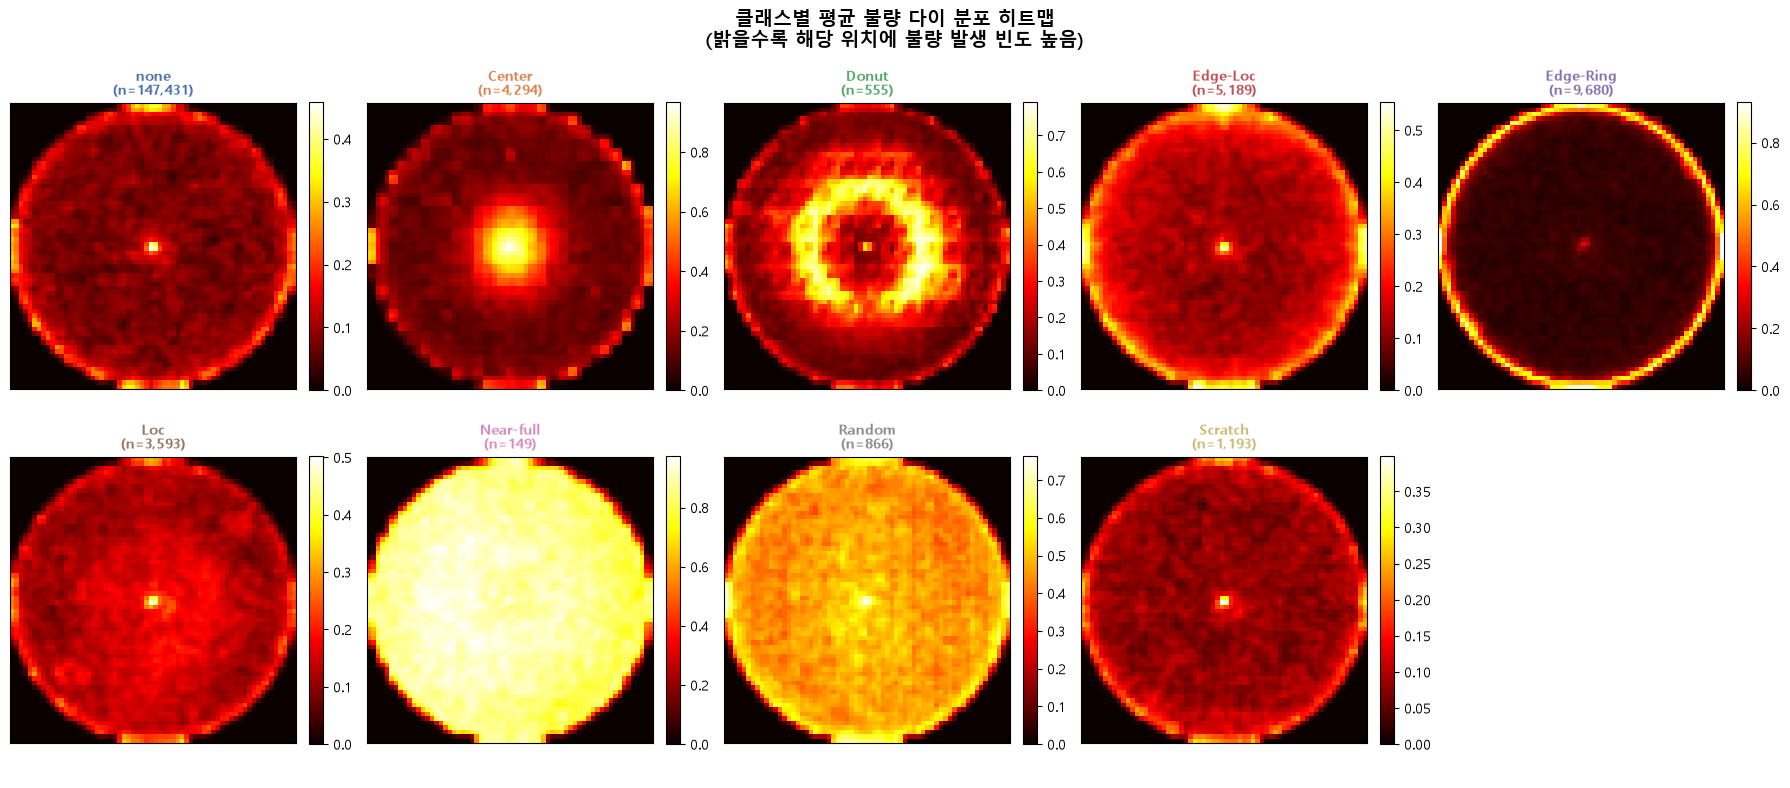

저장 완료: analysis\avg_defect_heatmap.png


In [7]:
fig, axes = plt.subplots(2, 5, figsize=(18, 8))
fig.suptitle('클래스별 평균 불량 다이 분포 히트맵\n(밝을수록 해당 위치에 불량 발생 빈도 높음)',
             fontsize=14, fontweight='bold')

axes_flat = axes.flatten()
for idx, cls in enumerate(CLASS_ORDER):
    ax = axes_flat[idx]
    im = ax.imshow(avg_maps[cls], cmap='hot', vmin=0, vmax=avg_maps[cls].max() + 1e-6)
    cnt = len(labeled_df[labeled_df['failureType_clean'] == cls])
    ax.set_title(f'{cls}\n(n={cnt:,})', fontsize=10, fontweight='bold', color=COLOR_MAP[cls])
    ax.set_xticks([])
    ax.set_yticks([])
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

# 빈 칸 숨기기
for idx in range(len(CLASS_ORDER), len(axes_flat)):
    axes_flat[idx].axis('off')

plt.tight_layout()
save_path = ANALYSIS_DIR / 'avg_defect_heatmap.png'
plt.savefig(save_path, bbox_inches='tight', dpi=150)
plt.show()
print(f'저장 완료: {save_path}')

## 7. 웨이퍼 맵 크기 분포 분석

In [8]:
# 크기 정보 추출
shapes = labeled_df['waferMap'].apply(
    lambda x: x.shape if hasattr(x, 'shape') else (0, 0)
)
heights = shapes.apply(lambda s: s[0])
widths  = shapes.apply(lambda s: s[1])
areas   = heights * widths

print('=== 웨이퍼 맵 크기 통계 ===')
print(f'고유 크기 종류: {shapes.nunique()}가지')
print(f'\n높이(H) — min:{heights.min()}, max:{heights.max()}, 평균:{heights.mean():.1f}, 중앙:{heights.median():.0f}')
print(f'너비(W) — min:{widths.min()}, max:{widths.max()}, 평균:{widths.mean():.1f}, 중앙:{widths.median():.0f}')
print(f'\n상위 10개 크기:')
shape_dist = shapes.value_counts()
for shape, cnt in shape_dist.head(10).items():
    print(f'  {str(shape):<12}  {cnt:>6,}개  ({cnt/len(shapes)*100:.1f}%)')

=== 웨이퍼 맵 크기 통계 ===
고유 크기 종류: 346가지

높이(H) — min:15, max:212, 평균:35.2, 중앙:33
너비(W) — min:3, max:204, 평균:34.8, 중앙:33

상위 10개 크기:
  (25, 27)      18,781개  (10.9%)
  (26, 26)      14,366개  (8.3%)
  (30, 34)      12,400개  (7.2%)
  (29, 26)      11,751개  (6.8%)
  (27, 25)      10,682개  (6.2%)
  (39, 37)      10,173개  (5.9%)
  (33, 29)       8,125개  (4.7%)
  (42, 44)       6,724개  (3.9%)
  (44, 41)       6,134개  (3.5%)
  (41, 33)       5,091개  (2.9%)


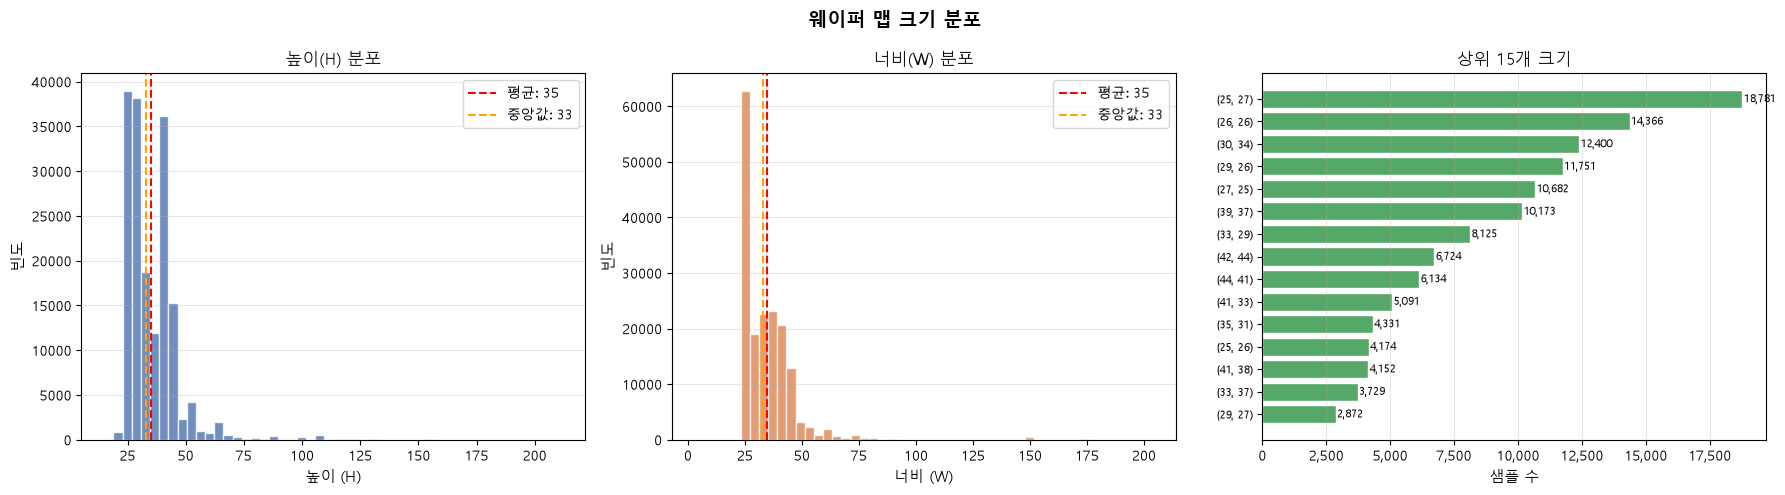

저장 완료: analysis\wafer_size_distribution.png


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('웨이퍼 맵 크기 분포', fontsize=14, fontweight='bold')

# 높이 분포
axes[0].hist(heights, bins=50, color='#4C72B0', edgecolor='white', alpha=0.8)
axes[0].axvline(heights.mean(), color='red', ls='--', label=f'평균: {heights.mean():.0f}')
axes[0].axvline(heights.median(), color='orange', ls='--', label=f'중앙값: {heights.median():.0f}')
axes[0].set_xlabel('높이 (H)', fontsize=11)
axes[0].set_ylabel('빈도', fontsize=11)
axes[0].set_title('높이(H) 분포', fontsize=12)
axes[0].legend(fontsize=10)
axes[0].grid(axis='y', alpha=0.3)

# 너비 분포
axes[1].hist(widths, bins=50, color='#DD8452', edgecolor='white', alpha=0.8)
axes[1].axvline(widths.mean(), color='red', ls='--', label=f'평균: {widths.mean():.0f}')
axes[1].axvline(widths.median(), color='orange', ls='--', label=f'중앙값: {widths.median():.0f}')
axes[1].set_xlabel('너비 (W)', fontsize=11)
axes[1].set_ylabel('빈도', fontsize=11)
axes[1].set_title('너비(W) 분포', fontsize=12)
axes[1].legend(fontsize=10)
axes[1].grid(axis='y', alpha=0.3)

# 상위 15개 크기 바 차트
top15 = shape_dist.head(15)
labels_15 = [str(s) for s in top15.index]
axes[2].barh(range(len(top15)), top15.values, color='#55A868', edgecolor='white')
axes[2].set_yticks(range(len(top15)))
axes[2].set_yticklabels(labels_15, fontsize=8)
axes[2].invert_yaxis()
axes[2].set_xlabel('샘플 수', fontsize=11)
axes[2].set_title('상위 15개 크기', fontsize=12)
axes[2].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[2].grid(axis='x', alpha=0.3)
for i, v in enumerate(top15.values):
    axes[2].text(v + 50, i, f'{v:,}', va='center', fontsize=8)

plt.tight_layout()
save_path = ANALYSIS_DIR / 'wafer_size_distribution.png'
plt.savefig(save_path, bbox_inches='tight', dpi=150)
plt.show()
print(f'저장 완료: {save_path}')

## 8. 픽셀값 통계 — 클래스별 불량 다이 비율

각 웨이퍼 맵에서 **불량 다이(픽셀=2) 비율** = 불량 다이 수 / 전체 다이 수(픽셀 > 0)

In [10]:
MAX_CALC = 500  # 클래스당 계산 샘플 수 (속도 조절)

def compute_defect_ratio(wmap):
    arr = np.array(wmap)
    total_dies = (arr > 0).sum()  # 빈 영역 제외
    if total_dies == 0:
        return 0.0
    return (arr == 2).sum() / total_dies

print('클래스별 불량 다이 비율 계산 중...')
defect_ratios = {}
for cls in CLASS_ORDER:
    cls_df = labeled_df[labeled_df['failureType_clean'] == cls]
    sample = cls_df.sample(n=min(MAX_CALC, len(cls_df)), random_state=SEED)
    ratios = sample['waferMap'].apply(compute_defect_ratio)
    defect_ratios[cls] = ratios
    print(f'  {cls:<12}: 평균={ratios.mean()*100:.2f}%, 최대={ratios.max()*100:.2f}%')

print('완료')

클래스별 불량 다이 비율 계산 중...
  none        : 평균=10.19%, 최대=24.52%
  Center      : 평균=23.02%, 최대=66.09%
  Donut       : 평균=27.72%, 최대=67.84%
  Edge-Loc    : 평균=18.47%, 최대=71.51%
  Edge-Ring   : 평균=15.06%, 최대=35.35%
  Loc         : 평균=14.71%, 최대=59.81%
  Near-full   : 평균=87.69%, 최대=100.00%
  Random      : 평균=48.05%, 최대=74.67%
  Scratch     : 평균=10.21%, 최대=39.30%
완료


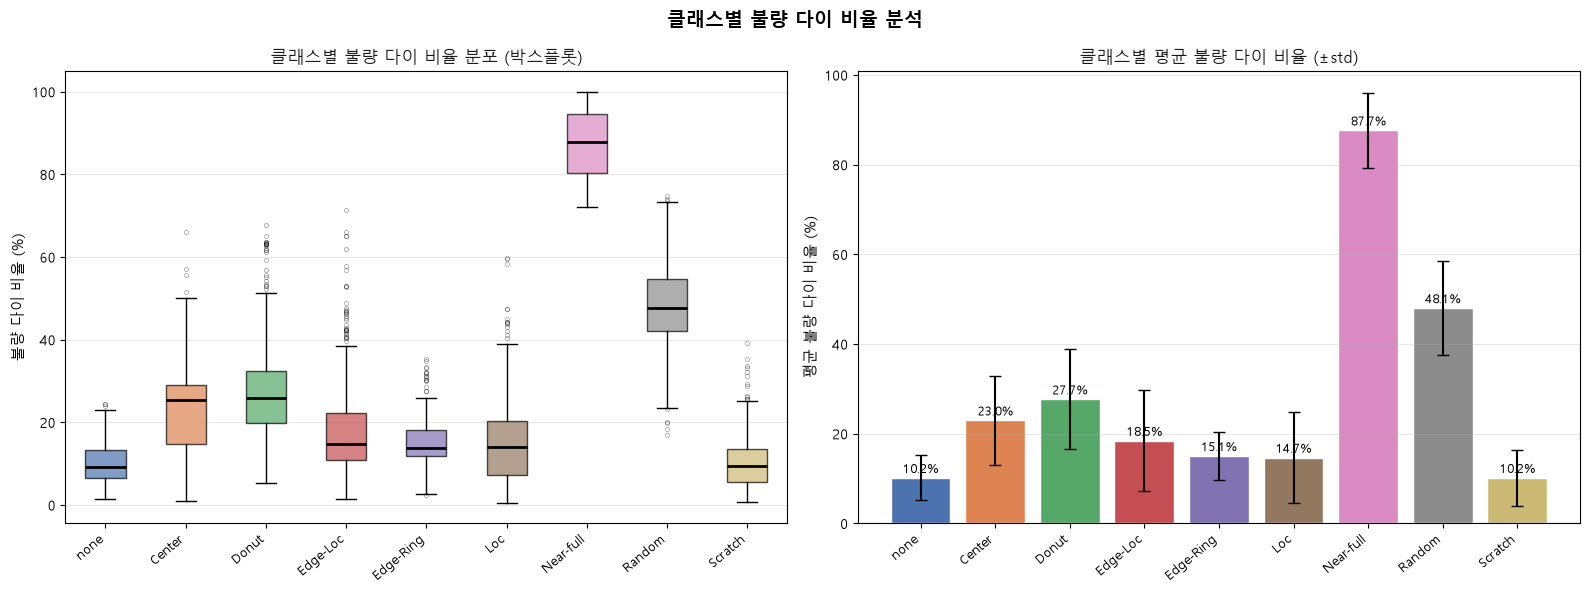

저장 완료: analysis\defect_ratio_analysis.png


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('클래스별 불량 다이 비율 분석', fontsize=14, fontweight='bold')

# ── 박스플롯
# matplotlib 3.10+에서 labels 파라미터 제거됨 → set_xticks/set_xticklabels 사용
# flierprops의 alpha도 post-hoc으로 처리해 버전 호환성 보장
ax1 = axes[0]
data_list = [defect_ratios[cls].values * 100 for cls in CLASS_ORDER]
bp = ax1.boxplot(data_list, patch_artist=True,
                 medianprops=dict(color='black', linewidth=2))

for patch, color in zip(bp['boxes'], CLASS_COLORS):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
for flier in bp['fliers']:
    flier.set(marker='o', markersize=3, alpha=0.4, markeredgewidth=0.5)

# boxplot x 좌표는 1부터 시작 (0-indexed 아님)
ax1.set_xticks(range(1, len(CLASS_ORDER) + 1))
ax1.set_xticklabels(CLASS_ORDER, rotation=40, ha='right', fontsize=9)
ax1.set_ylabel('불량 다이 비율 (%)', fontsize=11)
ax1.set_title('클래스별 불량 다이 비율 분포 (박스플롯)', fontsize=12)
ax1.grid(axis='y', alpha=0.3)

# ── 평균 바 차트
# 정수 x 위치 사용 → set_xticks/set_xticklabels 쌍으로 명시
ax2 = axes[1]
x_pos = list(range(len(CLASS_ORDER)))
means = [defect_ratios[cls].mean() * 100 for cls in CLASS_ORDER]
stds  = [defect_ratios[cls].std()  * 100 for cls in CLASS_ORDER]
bars  = ax2.bar(x_pos, means, color=CLASS_COLORS, edgecolor='white',
                yerr=stds, capsize=4, error_kw=dict(elinewidth=1.5))
ax2.set_xticks(x_pos)
ax2.set_xticklabels(CLASS_ORDER, rotation=40, ha='right', fontsize=9)
ax2.set_ylabel('평균 불량 다이 비율 (%)', fontsize=11)
ax2.set_title('클래스별 평균 불량 다이 비율 (±std)', fontsize=12)
ax2.grid(axis='y', alpha=0.3)
for bar, mean in zip(bars, means):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
             f'{mean:.1f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
save_path = ANALYSIS_DIR / 'defect_ratio_analysis.png'
plt.savefig(save_path, bbox_inches='tight', dpi=150)
plt.show()
print(f'저장 완료: {save_path}')

## 9. 클래스별 통계 요약 테이블

불량 다이 비율의 **mean, std, min, max, skewness, kurtosis**를 계산하여 저장한다.

In [12]:
rows = []
for cls in CLASS_ORDER:
    r = defect_ratios[cls] * 100
    cls_df = labeled_df[labeled_df['failureType_clean'] == cls]
    sh = cls_df['waferMap'].apply(lambda x: x.shape if hasattr(x, 'shape') else (0,0))
    rows.append({
        '클래스':        cls,
        '샘플 수':       len(cls_df),
        '비율(%)':       round(len(cls_df) / n_labeled * 100, 2),
        '불량다이_mean': round(r.mean(), 3),
        '불량다이_std':  round(r.std(),  3),
        '불량다이_min':  round(r.min(),  3),
        '불량다이_max':  round(r.max(),  3),
        '불량다이_skew': round(stats.skew(r), 3),
        '불량다이_kurt': round(stats.kurtosis(r), 3),
        '맵H_mean':      round(sh.apply(lambda s: s[0]).mean(), 1),
        '맵W_mean':      round(sh.apply(lambda s: s[1]).mean(), 1),
    })

summary_df = pd.DataFrame(rows)
print('=== 클래스별 통계 요약 ===')
print(summary_df.to_string(index=False))

# CSV 저장
csv_path = ANALYSIS_DIR / 'eda_summary.csv'
summary_df.to_csv(csv_path, index=False, encoding='utf-8-sig')
print(f'\n저장 완료: {csv_path}')

=== 클래스별 통계 요약 ===
      클래스   샘플 수  비율(%)  불량다이_mean  불량다이_std  불량다이_min  불량다이_max  불량다이_skew  불량다이_kurt  맵H_mean  맵W_mean
     none 147431  85.24     10.193     4.978     1.414    24.517      0.678     -0.164     33.9     33.3
   Center   4294   2.48     23.016     9.936     0.902    66.091     -0.049      0.401     31.9     33.1
    Donut    555   0.32     27.716    11.192     5.360    67.841      1.261      1.764     41.1     41.6
 Edge-Loc   5189   3.00     18.466    11.227     1.573    71.509      1.662      3.278     38.0     36.8
Edge-Ring   9680   5.60     15.064     5.280     2.546    35.353      0.837      1.603     52.8     53.9
      Loc   3593   2.08     14.708    10.090     0.515    59.815      1.037      2.062     39.3     38.0
Near-full    149   0.09     87.691     8.354    72.233   100.000     -0.106     -1.200     32.3     31.5
   Random    866   0.50     48.054    10.493    16.877    74.672     -0.105     -0.016     36.8     38.2
  Scratch   1193   0.69     10.210  

## 10. EDA 인사이트 요약 및 리포트 저장

In [13]:
imbalance_ratio = dist.max() / dist.min()
top3_defects    = dist.drop('none').nlargest(3)
rare_classes    = dist[dist < 1000]

print('=== EDA 핵심 인사이트 ===')
print()
print('[1] 데이터 규모')
print(f'    전체 811,457개 중 레이블 있는 데이터: 172,950개 (21.3%)')
print(f'    미레이블 데이터(unknown) 638,507개는 분석에서 제외')
print()
print('[2] 클래스 불균형 (심각)')
print(f'    Imbalance Ratio: {imbalance_ratio:.1f}x  (none {dist["none"]:,} vs Near-full {dist["Near-full"]})')
print(f'    정상(none)이 전체 레이블의 {dist["none"]/n_labeled*100:.1f}% 차지')
print(f'    소수 클래스 (1,000개 미만): {list(rare_classes.index)}')
print()
print('[3] 불량 패턴 특성 (히트맵 기반)')
print('    - Center:    웨이퍼 중심부에 불량 집중 → 결정 성장 / Annealing 공정 이슈')
print('    - Edge-Ring: 가장자리 링 형태 → 열처리 온도 구배 이슈')
print('    - Edge-Loc:  가장자리 국소 불량 → CMP 압력 불균일')
print('    - Scratch:   직선 형태 패턴 → 물리적 접촉 손상')
print('    - Random:    전체 분포 → 청정실 오염 환경')
print()
print('[4] 웨이퍼 맵 크기')
print(f'    고유 크기 {shapes.nunique()}가지, 가변 크기 → 64×64 고정 리사이징 필수')
print(f'    주요 크기: (32,29), (25,27), (49,39)')
print()
print('[5] 전처리 전략 결정')
print('    - 미레이블(unknown) 제거 → 172,950개 사용')
print('    - 64×64 리사이징 (cv2.resize)')
print('    - 픽셀값 0~2 → 0.0~1.0 정규화')
print('    - Weighted Random Sampler + Class Weight로 불균형 처리')
print('    - Albumentations: Rotate, Flip, GaussNoise, Cutout 적용')

=== EDA 핵심 인사이트 ===

[1] 데이터 규모
    전체 811,457개 중 레이블 있는 데이터: 172,950개 (21.3%)
    미레이블 데이터(unknown) 638,507개는 분석에서 제외

[2] 클래스 불균형 (심각)
    Imbalance Ratio: 989.5x  (none 147,431 vs Near-full 149)
    정상(none)이 전체 레이블의 85.2% 차지
    소수 클래스 (1,000개 미만): ['Random', 'Donut', 'Near-full']

[3] 불량 패턴 특성 (히트맵 기반)
    - Center:    웨이퍼 중심부에 불량 집중 → 결정 성장 / Annealing 공정 이슈
    - Edge-Ring: 가장자리 링 형태 → 열처리 온도 구배 이슈
    - Edge-Loc:  가장자리 국소 불량 → CMP 압력 불균일
    - Scratch:   직선 형태 패턴 → 물리적 접촉 손상
    - Random:    전체 분포 → 청정실 오염 환경

[4] 웨이퍼 맵 크기
    고유 크기 346가지, 가변 크기 → 64×64 고정 리사이징 필수
    주요 크기: (32,29), (25,27), (49,39)

[5] 전처리 전략 결정
    - 미레이블(unknown) 제거 → 172,950개 사용
    - 64×64 리사이징 (cv2.resize)
    - 픽셀값 0~2 → 0.0~1.0 정규화
    - Weighted Random Sampler + Class Weight로 불균형 처리
    - Albumentations: Rotate, Flip, GaussNoise, Cutout 적용


In [14]:
report = f"""# WM-811K EDA 리포트

## 1. 데이터 현황

| 항목 | 수치 |
|------|------|
| 전체 샘플 수 | 811,457개 |
| 레이블 있는 샘플 | 172,950개 (21.3%) |
| 미레이블 (unknown) | 638,507개 (78.7%) |
| 클래스 수 | 9종 불량 + none |

## 2. 클래스 분포

| 클래스 | 샘플 수 | 비율 |
|--------|--------|------|
{chr(10).join(f'| {r["클래스"]} | {r["샘플 수"]:,} | {r["비율(%)"]:.2f}% |' for _, r in summary_df.iterrows())}

**Imbalance Ratio: {imbalance_ratio:.1f}x** (none {dist['none']:,} vs Near-full {dist['Near-full']})

## 3. 불량 다이 비율 통계 (클래스별)

| 클래스 | 평균(%) | 표준편차 | Skewness | Kurtosis |
|--------|---------|---------|----------|----------|
{chr(10).join(f'| {r["클래스"]} | {r["불량다이_mean"]} | {r["불량다이_std"]} | {r["불량다이_skew"]} | {r["불량다이_kurt"]} |' for _, r in summary_df.iterrows())}

## 4. 웨이퍼 맵 크기

- 고유 크기 종류: {shapes.nunique()}가지
- 높이 범위: {heights.min()} ~ {heights.max()} (평균 {heights.mean():.1f})
- 너비 범위: {widths.min()} ~ {widths.max()} (평균 {widths.mean():.1f})
- 가변 크기 → **64×64 고정 리사이징** 필수

## 5. 전처리 전략 결정

| 항목 | 결정 사항 |
|------|----------|
| 데이터 필터링 | unknown 제거 → 172,950개 사용 |
| 크기 통일 | 64×64 (cv2.resize, INTER_AREA) |
| 정규화 | 픽셀값 0~2 → 0.0~1.0 |
| 클래스 불균형 처리 | Weighted Random Sampler + Class Weight |
| 데이터 증강 | Albumentations: Rotate±20°, HFlip, VFlip, GaussNoise, Cutout |

## 6. 산출물 목록

- `analysis/class_distribution.png`
- `analysis/sample_gallery.png`
- `analysis/avg_defect_heatmap.png`
- `analysis/wafer_size_distribution.png`
- `analysis/defect_ratio_analysis.png`
- `analysis/eda_summary.csv`
- `analysis/eda_report.md` (이 파일)
"""

report_path = ANALYSIS_DIR / 'eda_report.md'
with open(report_path, 'w', encoding='utf-8') as f:
    f.write(report)

print(f'EDA 리포트 저장 완료: {report_path}')
print()
print('=== Phase 1 Step 2 (EDA) 완료 ===')
print('다음 단계: 03_preprocessing.ipynb')

EDA 리포트 저장 완료: analysis\eda_report.md

=== Phase 1 Step 2 (EDA) 완료 ===
다음 단계: 03_preprocessing.ipynb
